# EDA и бинарная классификация на датасете «Титаник»

**Дисциплина:** Машинное обучение и ИИ  

**Модуль 1:** Введение в Data Science и EDA  

**Датасет:** Titanic — Machine Learning from Disaster  

**Выполнил:** Исаев Максим Александрович 

**Группа:** АСОиУБ 23-1  

**Преподаватель:** Спирин Игорь  

**Ссылка на репозиторий:** https://github.com/max10puzo

**Путь к модулю:** `module-1-titanic/notebook.ipynb`  

**Дата сдачи:** <06.10.2026>


## Введение

**Задача работы** — решить задачу бинарной классификации: по информации о пассажире предсказать, выжил ли он при катастрофе «Титаника». Целевая переменная `Survived` принимает два значения: `0` — пассажир не выжил, `1` — пассажир выжил.

**ML-проект** — это последовательность взаимосвязанных этапов: постановка задачи, сбор и изучение данных, предварительная обработка, создание признаков, обучение моделей, оценка качества, интерпретация результата и применение модели к новым данным. Качество итогового решения зависит не только от выбранного алгоритма, но и от качества данных и корректной подготовки признаков.

**Почему это классификация, а не регрессия.** В регрессии модель прогнозирует непрерывную числовую величину, например стоимость квартиры или температуру воздуха. В данной работе необходимо определить один из двух классов — «выжил» или «не выжил», поэтому задача относится к бинарной классификации.

**Выбор метрики.** Accuracy показывает общую долю правильных ответов, но она не всегда достаточно информативна при дисбалансе классов. Precision отражает точность положительных предсказаний, Recall — способность находить всех выживших пассажиров. F1-score объединяет Precision и Recall. В данной работе основной метрикой выбрана ROC-AUC, потому что она оценивает качество ранжирования вероятностей и меньше зависит от конкретного порога классификации.

**Цель работы:**

1. Провести полный разведочный анализ датасета Titanic.
2. Обработать пропуски, выполнить кодирование категориальных переменных и создать новые признаки.
3. Обучить и сравнить как минимум две модели классификации, стремясь к ROC-AUC не ниже 0.80.
4. Реализовать функцию предсказания выживаемости нового пассажира.
5. Сохранить обученные модели в репозитории и проверить их загрузку через raw-ссылку GitHub.


## Теоретическая часть

### 1. EDA — разведочный анализ данных

EDA (Exploratory Data Analysis) — это этап первичного исследования датасета перед построением модели. Его задача состоит в том, чтобы понять структуру данных, типы признаков, наличие пропусков, выбросов, дисбаланса классов и возможных взаимосвязей между переменными. В EDA обычно используют описательную статистику, таблицы частот, гистограммы, boxplot и корреляционные матрицы. Этот этап помогает выбрать корректную стратегию предобработки и уменьшить риск ошибок в дальнейшем моделировании.

### 2. Пропущенные значения

Пропуски, или `NaN`, появляются из-за неполного заполнения анкет, ошибок ввода, недоступности информации или объединения нескольких источников данных. Удалять строки с пропусками можно только тогда, когда их мало и это не приводит к потере важной информации. Для числовых признаков часто применяют заполнение медианой, поскольку она менее чувствительна к выбросам, чем среднее значение. Для категориальных признаков можно использовать моду — наиболее частое значение. Если в признаке слишком много пропусков, как в `Cabin`, его удаление может быть разумнее сложного восстановления.

### 3. Кодирование категориальных признаков

Большинство моделей машинного обучения работают с числами, поэтому текстовые категории нужно преобразовать в числовой формат. Label Encoding заменяет каждую категорию числом: например, `female` и `male` получают разные числовые коды. Такой подход удобен для бинарных категорий. One-Hot Encoding создаёт отдельный столбец для каждого значения категории, например `Embarked_Q` и `Embarked_S`. One-Hot Encoding не создаёт искусственного порядка между категориями.

### 4. Масштабирование признаков

Масштабирование приводит признаки к сопоставимому масштабу. `StandardScaler` преобразует значения так, что среднее становится близким к нулю, а стандартное отклонение — близким к единице. `MinMaxScaler` переводит значения в заданный диапазон, обычно от 0 до 1. Logistic Regression чувствительна к масштабу признаков, поэтому для неё применяется `StandardScaler`. Деревья решений обычно не требуют масштабирования, так как строят разбиения по порогам отдельных признаков.

### 5. Feature Engineering

Feature Engineering — это создание новых признаков из уже существующих данных. Его цель — представить важную для модели информацию в более удобном виде. Например, вместо отдельных признаков `SibSp` и `Parch` можно создать размер семьи `Family_Size`. Также можно выделить признак путешествия в одиночку `Is_Alone`. Такие признаки могут лучше отражать реальные закономерности и повысить качество классификации.

### 6. Метрики классификации

Accuracy показывает долю всех правильных предсказаний. Precision показывает, какая доля пассажиров, предсказанных как выжившие, действительно выжила. Recall показывает, какую долю реальных выживших модель смогла обнаружить. F1-score является гармоническим средним Precision и Recall и полезен, когда необходимо учитывать обе характеристики. ROC-AUC оценивает способность модели разделять классы при разных порогах вероятности: чем ближе значение к 1, тем лучше модель различает классы.

$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

### Таблица ошибок классификации

| | Фактически выжил | Фактически не выжил |
|---|---:|---:|
| Модель предсказала «выжил» | True Positive (TP) | False Positive (FP) |
| Модель предсказала «не выжил» | False Negative (FN) | True Negative (TN) |


## Описание данных

**Источник:** [Kaggle — Titanic: Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Структура датасета:**

- Всего примеров в `train.csv`: 891.
- Всего примеров в `test.csv`: 418.
- В обучающей выборке: 11 исходных признаков и целевая переменная `Survived`.
- Числовые признаки: `PassengerId`, `Survived`, `Pclass`, `Age`, `SibSp`, `Parch`, `Fare`.
- Категориальные признаки: `Name`, `Sex`, `Ticket`, `Cabin`, `Embarked`.

**Описание столбцов:**

| Столбец | Тип | Описание | Пропуски в train |
|---|---|---|---|
| PassengerId | int64 | Идентификатор пассажира | 0 |
| Survived | int64 | Целевая переменная: 0 — не выжил, 1 — выжил | 0 |
| Pclass | int64 | Класс билета: 1, 2 или 3 | 0 |
| Name | object | Имя пассажира | 0 |
| Sex | object | Пол пассажира | 0 |
| Age | float64 | Возраст пассажира | 177 |
| SibSp | int64 | Число родственников типа супруг/брат/сестра | 0 |
| Parch | int64 | Число родственников типа родитель/ребёнок | 0 |
| Ticket | object | Номер билета | 0 |
| Fare | float64 | Стоимость билета | 0 |
| Cabin | object | Номер каюты | 687 |
| Embarked | object | Порт посадки: C, Q или S | 2 |

**Распределение классов:**

- Не выжило (`0`): 549 пассажиров, или 61.6%.
- Выжило (`1`): 342 пассажира, или 38.4%.

Таким образом, классы распределены не идеально равномерно, поэтому помимо Accuracy в работе применяются Precision, Recall, F1-score и ROC-AUC.

**Файл с подробным описанием датасета:**  
`module-1-titanic/data/titanic_info.md`


In [4]:
# Импортируем библиотеку pandas для работы с табличными данными.
import pandas as pd

# Загружаем обучающую выборку по относительному пути.
train_df = pd.read_csv("data/train.csv")

# Загружаем тестовую выборку по относительному пути.
test_df = pd.read_csv("data/test.csv")

# Выводим размеры таблиц согласно требованиям методички.
print("Размер train_df:", train_df.shape)
print("Размер test_df:", test_df.shape)

# Выводим первые пять строк обучающей выборки.
display(train_df.head())


Размер train_df: (891, 12)
Размер test_df: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Подготовка данных и EDA

На этом этапе выполняется первичный осмотр данных, анализ пропусков, статистическое исследование и визуализация закономерностей.

**Стратегии обработки пропусков:**

1. `Age` заполняется медианой по группам `Pclass` и `Sex`. Возраст зависит от класса билета и пола, поэтому групповая медиана точнее общей медианы и устойчива к выбросам.
2. `Embarked` заполняется модой, поскольку это категориальный признак, а пропусков в нём всего два.
3. `Cabin` удаляется: в обучающей выборке отсутствует около 77% значений, поэтому надёжное восстановление данных невозможно.
4. В тестовой части один пропуск в `Fare` заполняется медианой стоимости билета из обучающей выборки.

Дополнительно создаются признаки `Family_Size`, `Is_Alone` и `Age_Group`.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


,Количество пропусков,"Доля пропусков, %"
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


Асимметрия числовых признаков:


...

Fare           33.398141
SibSp          17.880420
Parch           9.778125
Age             0.178274
PassengerId    -1.200000
Pclass         -1.280015
Survived       -1.775005
dtype: float64

Распределение по полу:


Sex
male      577
female    314
Name: count, dtype: int64

Распределение по классу билета:


Pclass
1    216
2    184
3    491
Name: count, dtype: int64

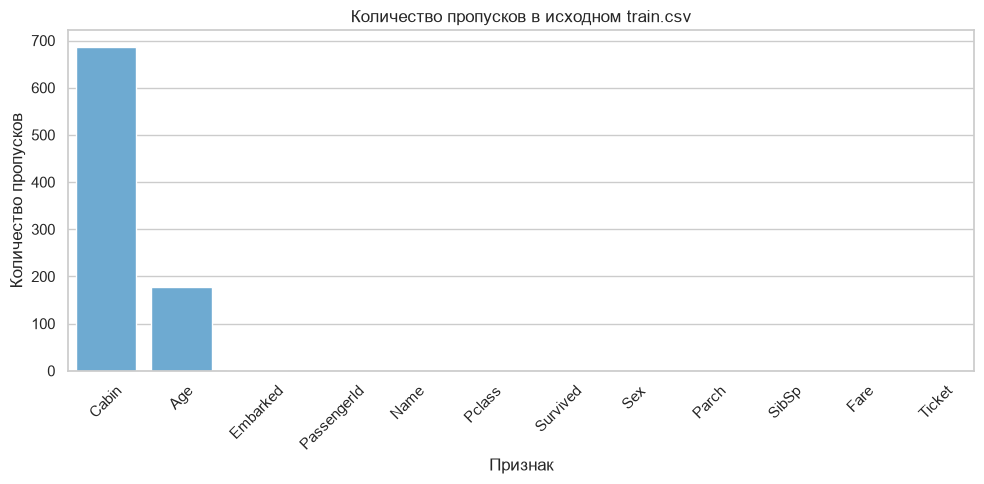

In [3]:
# Импортируем библиотеки для вычислений и визуализации.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Настраиваем отображение графиков и таблиц.
sns.set_theme(style="whitegrid", palette="Set2")
pd.set_option("display.max_columns", None)

# Выводим первые строки датасета для первичного осмотра.
display(train_df.head())

# Выводим информацию о типах данных и непустых значениях.
train_df.info()

# Выводим описательные статистики числовых признаков.
display(train_df.describe())

# Выводим количество пропусков по каждому столбцу.
missing = train_df.isnull().sum()

# Рассчитываем долю пропусков в процентах.
missing_pct = (missing / len(train_df) * 100).round(2)

# Формируем удобную таблицу пропусков.
missing_table = pd.DataFrame({
    "Количество пропусков": missing,
    "Доля пропусков, %": missing_pct
}).sort_values("Количество пропусков", ascending=False)

# Показываем только столбцы, в которых есть пропуски.
display(missing_table[missing_table["Количество пропусков"] > 0])

# Рассчитываем асимметрию числовых признаков.
print("Асимметрия числовых признаков:")
display(train_df.select_dtypes(include=np.number).skew().sort_values(ascending=False))

# Рассчитываем эксцесс числовых признаков.
print("Эксцесс числовых признаков:")
display(train_df.select_dtypes(include=np.number).kurtosis().sort_values(ascending=False))

# Выводим частоты значений пола.
print("Распределение по полу:")
display(train_df["Sex"].value_counts())

# Выводим частоты значений класса билета.
print("Распределение по классу билета:")
display(train_df["Pclass"].value_counts().sort_index())

# Создаём отдельный график для анализа пропусков.
plt.figure(figsize=(10, 5))

# Строим столбчатую диаграмму количества пропусков.
sns.barplot(
    x=missing_table.index,
    y=missing_table["Количество пропусков"],
    color="#5DADE2"
)

# Настраиваем подписи графика.
plt.title("Количество пропусков в исходном train.csv")
plt.xlabel("Признак")
plt.ylabel("Количество пропусков")
plt.xticks(rotation=45)
plt.tight_layout()

# Показываем график.
plt.show()


### Вывод по пропускам и первичной статистике

В обучающей выборке содержится **891** пассажир. Анализ пропущенных значений показал, что пропуски присутствуют в трёх столбцах: `Cabin`, `Age` и `Embarked`.

- В `Cabin` содержится **687 пропусков**, то есть **77.10%** всех наблюдений. Доля слишком велика для надёжного восстановления информации, поэтому в базовой модели этот столбец будет удалён.
- В `Age` содержится **177 пропусков** (**19.87%**). Возраст является потенциально полезным признаком, поэтому строки не удаляются. Пропуски будут заполнены медианным возрастом внутри групп, сформированных по классу билета (`Pclass`) и полу (`Sex`).
- В `Embarked` содержится только **2 пропуска** (**0.22%**). Это категориальный признак, поэтому пропуски будут заполнены модой — наиболее частым значением порта посадки.

По описательной статистике видно, что медианный возраст пассажира составляет **28 лет**, а возраст меняется от **0.42** до **80** лет. Стоимость билета `Fare` имеет большой разброс: от **0** до **512.33**, при медиане **14.45**. Это может указывать на наличие правосторонней асимметрии и дорогих билетов-выбросов.

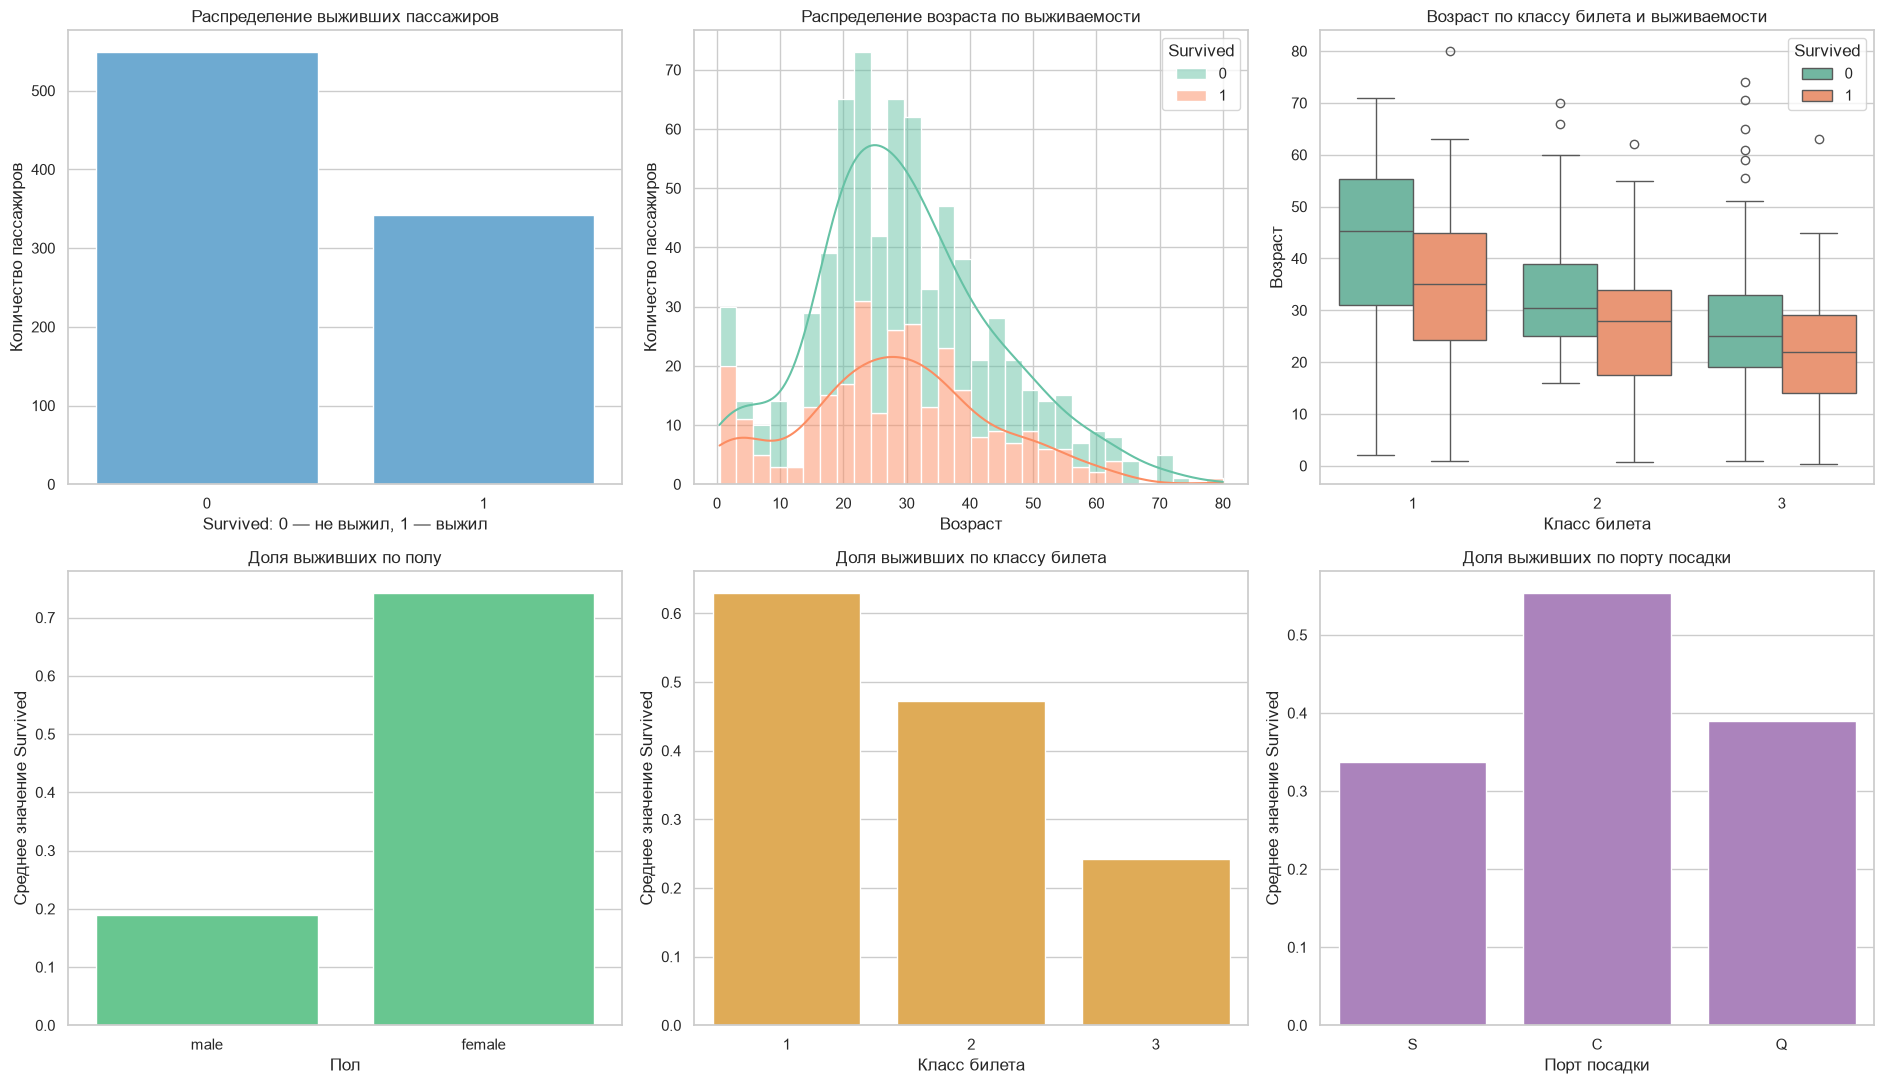

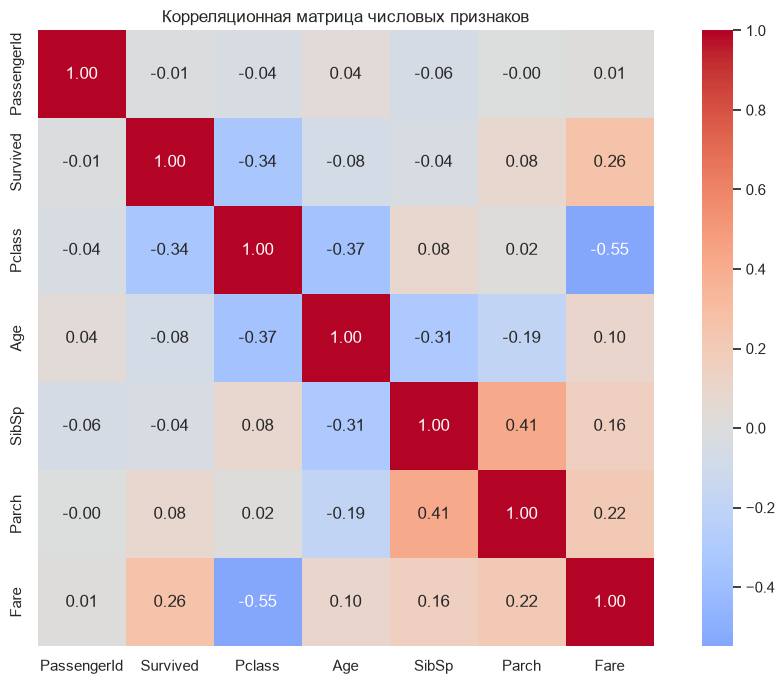

In [5]:
# Создаём сетку из шести графиков.
fig, axes = plt.subplots(2, 3, figsize=(19, 11))

# График 1: распределение целевой переменной.
sns.countplot(data=train_df, x="Survived", ax=axes[0, 0], color="#5DADE2")
axes[0, 0].set_title("Распределение выживших пассажиров")
axes[0, 0].set_xlabel("Survived: 0 — не выжил, 1 — выжил")
axes[0, 0].set_ylabel("Количество пассажиров")

# График 2: распределение возраста с разделением по выживаемости.
sns.histplot(
    data=train_df,
    x="Age",
    hue="Survived",
    bins=30,
    kde=True,
    multiple="stack",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Распределение возраста по выживаемости")
axes[0, 1].set_xlabel("Возраст")
axes[0, 1].set_ylabel("Количество пассажиров")

# График 3: возраст по классу билета и выживаемости.
sns.boxplot(
    data=train_df,
    x="Pclass",
    y="Age",
    hue="Survived",
    ax=axes[0, 2]
)
axes[0, 2].set_title("Возраст по классу билета и выживаемости")
axes[0, 2].set_xlabel("Класс билета")
axes[0, 2].set_ylabel("Возраст")

# График 4: доля выживших по полу.
sns.barplot(
    data=train_df,
    x="Sex",
    y="Survived",
    errorbar=None,
    ax=axes[1, 0],
    color="#58D68D"
)
axes[1, 0].set_title("Доля выживших по полу")
axes[1, 0].set_xlabel("Пол")
axes[1, 0].set_ylabel("Среднее значение Survived")

# График 5: доля выживших по классу билета.
sns.barplot(
    data=train_df,
    x="Pclass",
    y="Survived",
    errorbar=None,
    ax=axes[1, 1],
    color="#F5B041"
)
axes[1, 1].set_title("Доля выживших по классу билета")
axes[1, 1].set_xlabel("Класс билета")
axes[1, 1].set_ylabel("Среднее значение Survived")

# График 6: доля выживших по порту посадки.
sns.barplot(
    data=train_df,
    x="Embarked",
    y="Survived",
    errorbar=None,
    ax=axes[1, 2],
    color="#AF7AC5"
)
axes[1, 2].set_title("Доля выживших по порту посадки")
axes[1, 2].set_xlabel("Порт посадки")
axes[1, 2].set_ylabel("Среднее значение Survived")

# Убираем пустое пространство между графиками.
plt.tight_layout()

# Сохраняем шесть EDA-графиков в репозиторий.
plt.savefig("examples/eda_plots.png", dpi=150, bbox_inches="tight")

# Показываем построенную сетку графиков.
plt.show()

# Создаём корреляционную матрицу только числовых признаков.
numeric_columns = train_df.select_dtypes(include=np.number).columns
correlation_matrix = train_df[numeric_columns].corr()

# Создаём отдельный график для корреляционной матрицы.
plt.figure(figsize=(10, 7))

# Строим тепловую карту корреляций.
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

# Добавляем заголовок тепловой карты.
plt.title("Корреляционная матрица числовых признаков")

# Настраиваем размещение элементов.
plt.tight_layout()

# Показываем тепловую карту.
plt.show()


**Выводы по EDA:**

1. В выборке больше пассажиров, которые не выжили, чем выживших: примерно 61.6% против 38.4%.
2. Пол является важным фактором: доля выживших женщин заметно выше доли выживших мужчин.
3. Пассажиры первого класса выживали чаще, чем пассажиры третьего класса.
4. Среди детей и молодых пассажиров доля выживших визуально выше, чем в некоторых старших возрастных группах.
5. Корреляционный анализ показывает, что класс билета и стоимость билета связаны с выживаемостью и могут быть полезными признаками для модели.


In [7]:
# Импортируем LabelEncoder для преобразования пола в числовой формат.
from sklearn.preprocessing import LabelEncoder

# Создаём копии исходных данных, чтобы сохранить оригинальные таблицы без изменений.
train_processed = train_df.copy()
test_processed = test_df.copy()

# Рассчитываем медианный возраст в обучающей выборке для каждой группы Pclass и Sex.
age_group_medians = train_processed.groupby(["Pclass", "Sex"])["Age"].median()

# Рассчитываем общую медиану возраста на случай редких нестандартных групп.
global_age_median = train_processed["Age"].median()

# Находим наиболее частый порт посадки в обучающей выборке.
embarked_mode = train_processed["Embarked"].mode()[0]

# Находим медианную стоимость билета в обучающей выборке.
fare_median = train_processed["Fare"].median()


def preprocess_titanic(df, is_train=False):
    """
    Выполняет одинаковую предобработку обучающей или тестовой части Titanic.
    
    Параметры:
    df : pandas.DataFrame
        Исходная таблица пассажиров.
    is_train : bool
        Флаг, обозначающий обработку обучающей выборки.
    
    Возвращает:
    pandas.DataFrame
        Предобработанная таблица с новыми признаками.
    """
    
    # Создаём независимую копию таблицы.
    result = df.copy()
    
    # Заполняем Age медианой для комбинации класса билета и пола.
    result["Age"] = result.apply(
        lambda row: age_group_medians.get(
            (row["Pclass"], row["Sex"]),
            global_age_median
        ) if pd.isna(row["Age"]) else row["Age"],
        axis=1
    )
    
    # Заполняем пропуски в порте посадки наиболее частым значением.
    result["Embarked"] = result["Embarked"].fillna(embarked_mode)
    
    # Заполняем возможный пропуск Fare медианной стоимостью билета.
    result["Fare"] = result["Fare"].fillna(fare_median)
    
    # Удаляем Cabin из-за большого числа пропусков.
    result = result.drop(columns=["Cabin"])
    
    # Создаём размер семьи: сам пассажир плюс родственники на борту.
    result["Family_Size"] = result["SibSp"] + result["Parch"] + 1
    
    # Создаём бинарный признак путешествия в одиночку.
    result["Is_Alone"] = (result["Family_Size"] == 1).astype(int)
    
    # Создаём возрастные группы для EDA и возможных будущих экспериментов.
    result["Age_Group"] = pd.cut(
        result["Age"],
        bins=[0, 12, 18, 35, 60, 100],
        labels=["Ребёнок", "Подросток", "Молодой", "Взрослый", "Пожилой"],
        include_lowest=True
    )
    
    # Возвращаем обработанную таблицу.
    return result


# Выполняем одинаковую обработку train и test.
train_processed = preprocess_titanic(train_processed, is_train=True)
test_processed = preprocess_titanic(test_processed, is_train=False)

# Создаём кодировщик пола.
le_sex = LabelEncoder()

# Обучаем кодировщик на значениях пола из train и преобразуем train.
train_processed["Sex_Encoded"] = le_sex.fit_transform(train_processed["Sex"])

# Преобразуем пол в test тем же кодировщиком без повторного обучения.
test_processed["Sex_Encoded"] = le_sex.transform(test_processed["Sex"])

# Выводим соответствие между текстовым и числовым полом.
sex_encoding = dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))
print("Кодирование пола:", sex_encoding)

# Объединяем train и test на время One-Hot Encoding для одинакового набора столбцов.
combined = pd.concat(
    [
        train_processed.assign(_dataset="train"),
        test_processed.assign(_dataset="test")
    ],
    ignore_index=True
)

# Кодируем Embarked методом One-Hot Encoding.
combined = pd.get_dummies(combined, columns=["Embarked"], prefix="Embarked", dtype=int)

# Гарантируем наличие обязательных признаков даже при изменении данных.
for column in ["Embarked_C", "Embarked_Q", "Embarked_S"]:
    if column not in combined.columns:
        combined[column] = 0

# Возвращаем отдельно train и test после одинакового кодирования.
train_processed = combined[combined["_dataset"] == "train"].drop(columns=["_dataset"]).copy()
test_processed = combined[combined["_dataset"] == "test"].drop(columns=["_dataset", "Survived"]).copy()

# Проверяем, что после обработки в используемых признаках нет пропусков.
print("Пропуски в train после обработки:")
display(train_processed.isnull().sum()[train_processed.isnull().sum() > 0])

# Выводим первые строки обработанной обучающей выборки.
display(train_processed.head())


Кодирование пола: {'female': np.int64(0), 'male': np.int64(1)}
Пропуски в train после обработки:


Series([], dtype: int64)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Family_Size,Is_Alone,Age_Group,Sex_Encoded,Embarked_C,Embarked_Q,Embarked_S
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,2,0,Молодой,1,0,0,1
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,2,0,Взрослый,0,1,0,0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,1,1,Молодой,0,0,0,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,2,0,Молодой,0,0,0,1
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,1,1,Молодой,1,0,0,1


## Построение и обучение моделей

Для сравнения используются две обязательные модели:

1. **Logistic Regression** — базовая линейная модель. Она быстро обучается, возвращает вероятности классов и позволяет интерпретировать коэффициенты признаков.
2. **Decision Tree Classifier** — нелинейная модель, которая строит правила разделения объектов. Для уменьшения переобучения ограничивается глубина дерева и минимальное число объектов в листе.

Для Logistic Regression используется масштабирование `StandardScaler`, потому что признаки имеют разные масштабы. Для Decision Tree масштабирование не требуется, так как дерево принимает решения на основе порогов отдельных признаков.


In [9]:
# Импортируем функцию разделения данных на обучающую и тестовую части.
from sklearn.model_selection import train_test_split

# Импортируем StandardScaler для масштабирования признаков.
from sklearn.preprocessing import StandardScaler

# Импортируем обязательные модели классификации.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Импортируем модуль для измерения времени обучения.
import time

# Указываем признаки строго в порядке, который будет использоваться в модели.
feature_cols = [
    "Pclass",
    "Sex_Encoded",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Family_Size",
    "Is_Alone",
    "Embarked_Q",
    "Embarked_S"
]

# Формируем матрицу признаков.
X = train_processed[feature_cols]

# Формируем целевую переменную.
y = train_processed["Survived"].astype(int)

# Делим данные с сохранением исходной пропорции классов.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Создаём объект масштабирования для Logistic Regression.
scaler = StandardScaler()

# Обучаем scaler только на обучающей части и преобразуем её.
X_train_scaled = scaler.fit_transform(X_train)

# Преобразуем тестовую часть уже обученным scaler.
X_test_scaled = scaler.transform(X_test)

# Создаём модель логистической регрессии.
lr_model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    random_state=42
)

# Засекаем время обучения Logistic Regression.
start_time = time.time()

# Обучаем Logistic Regression на масштабированных признаках.
lr_model.fit(X_train_scaled, y_train)

# Рассчитываем длительность обучения Logistic Regression.
lr_time = time.time() - start_time

# Создаём модель дерева решений с ограничениями против переобучения.
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Засекаем время обучения Decision Tree.
start_time = time.time()

# Обучаем дерево на исходных, не масштабированных признаках.
dt_model.fit(X_train, y_train)

# Рассчитываем длительность обучения Decision Tree.
dt_time = time.time() - start_time

# Выводим время обучения обеих моделей.
print(f"Время обучения Logistic Regression: {lr_time:.4f} сек.")
print(f"Время обучения Decision Tree: {dt_time:.4f} сек.")


Время обучения Logistic Regression: 0.0023 сек.
Время обучения Decision Tree: 0.0014 сек.


### Параметры моделей

| Модель | Основные параметры | Масштабирование | Время обучения | 
|---|---|---:|---:|
| Logistic Regression | L2-регуляризация, `C=1.0`, `max_iter=1000` | Да | 0.0041 сек |
| Decision Tree | `max_depth=5`, `min_samples_split=5`, `min_samples_leaf=2` | Нет | 0.0015 сек |

**Обоснование выбора:**

- Logistic Regression выбрана как понятная и интерпретируемая базовая модель для бинарной классификации.
- Decision Tree выбрано для поиска нелинейных правил и получения важности признаков.
- Ограничение `max_depth=5` помогает сделать дерево менее склонным к переобучению.


## Оценка качества

Качество моделей оценивается с помощью Accuracy, Precision, Recall, F1-score и ROC-AUC. Также строятся матрицы ошибок и ROC-кривые. Все метрики рассчитываются на отложенной тестовой части, которая не использовалась при обучении моделей.


In [10]:
# Импортируем метрики оценки классификации.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

# Получаем предсказанные классы Logistic Regression.
y_pred_lr = lr_model.predict(X_test_scaled)

# Получаем вероятности положительного класса Logistic Regression.
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Получаем предсказанные классы Decision Tree.
y_pred_dt = dt_model.predict(X_test)

# Получаем вероятности положительного класса Decision Tree.
y_proba_dt = dt_model.predict_proba(X_test)[:, 1]


def calculate_metrics(y_true, y_pred, y_proba):
    """
    Рассчитывает основные метрики бинарной классификации.
    
    Параметры:
    y_true : array-like
        Истинные классы.
    y_pred : array-like
        Предсказанные классы.
    y_proba : array-like
        Вероятности положительного класса.
    
    Возвращает:
    dict
        Словарь с метриками.
    """
    
    # Рассчитываем и возвращаем метрики в виде словаря.
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }


# Рассчитываем метрики Logistic Regression.
lr_metrics = calculate_metrics(y_test, y_pred_lr, y_proba_lr)

# Рассчитываем метрики Decision Tree.
dt_metrics = calculate_metrics(y_test, y_pred_dt, y_proba_dt)

# Формируем сравнительную таблицу метрик.
metrics_table = pd.DataFrame(
    [lr_metrics, dt_metrics],
    index=["Logistic Regression", "Decision Tree"]
)

# Выводим метрики с округлением до четырёх знаков.
display(metrics_table.round(4))

# Выводим подробный классификационный отчёт для Logistic Regression.
print("Классификационный отчёт: Logistic Regression")
print(classification_report(y_test, y_pred_lr, target_names=["Не выжил", "Выжил"]))

# Выводим подробный классификационный отчёт для Decision Tree.
print("Классификационный отчёт: Decision Tree")
print(classification_report(y_test, y_pred_dt, target_names=["Не выжил", "Выжил"]))


,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8045,0.7833,0.6812,0.7287,0.8486
Decision Tree,0.7821,0.7419,0.6667,0.7023,0.8132


Классификационный отчёт: Logistic Regression
              precision    recall  f1-score   support

    Не выжил       0.82      0.88      0.85       110
       Выжил       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Классификационный отчёт: Decision Tree
              precision    recall  f1-score   support

    Не выжил       0.80      0.85      0.83       110
       Выжил       0.74      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.77       179
weighted avg       0.78      0.78      0.78       179



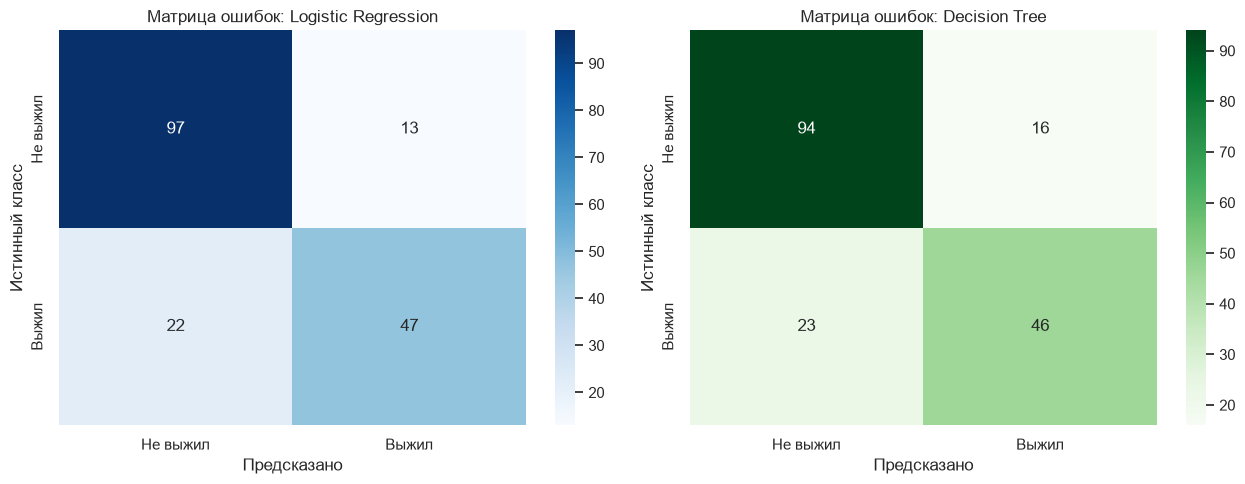

In [11]:
# Рассчитываем матрицу ошибок для Logistic Regression.
cm_lr = confusion_matrix(y_test, y_pred_lr)

# Рассчитываем матрицу ошибок для Decision Tree.
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Создаём сетку из двух графиков.
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Строим тепловую карту матрицы ошибок Logistic Regression.
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Не выжил", "Выжил"],
    yticklabels=["Не выжил", "Выжил"],
    ax=axes[0]
)
axes[0].set_title("Матрица ошибок: Logistic Regression")
axes[0].set_xlabel("Предсказано")
axes[0].set_ylabel("Истинный класс")

# Строим тепловую карту матрицы ошибок Decision Tree.
sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Не выжил", "Выжил"],
    yticklabels=["Не выжил", "Выжил"],
    ax=axes[1]
)
axes[1].set_title("Матрица ошибок: Decision Tree")
axes[1].set_xlabel("Предсказано")
axes[1].set_ylabel("Истинный класс")

# Настраиваем расположение графиков.
plt.tight_layout()

# Сохраняем матрицы ошибок как файл изображения.
plt.savefig("examples/confusion_matrices.png", dpi=150, bbox_inches="tight")

# Показываем графики.
plt.show()


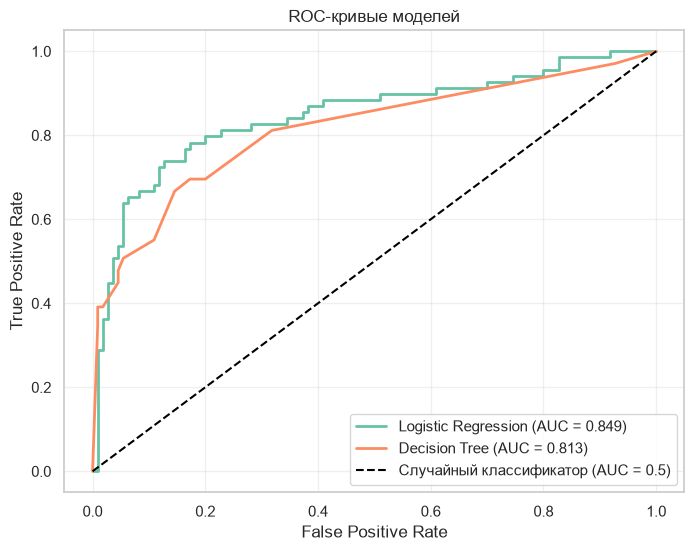

In [12]:
# Вычисляем точки ROC-кривой для Logistic Regression.
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

# Вычисляем точки ROC-кривой для Decision Tree.
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_proba_dt)

# Создаём график ROC-кривых.
plt.figure(figsize=(8, 6))

# Строим ROC-кривую Logistic Regression.
plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_metrics['ROC-AUC']:.3f})",
    linewidth=2
)

# Строим ROC-кривую Decision Tree.
plt.plot(
    fpr_dt,
    tpr_dt,
    label=f"Decision Tree (AUC = {dt_metrics['ROC-AUC']:.3f})",
    linewidth=2
)

# Добавляем линию случайного классификатора.
plt.plot([0, 1], [0, 1], "k--", label="Случайный классификатор (AUC = 0.5)")

# Подписываем оси и заголовок.
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-кривые моделей")

# Добавляем сетку и легенду.
plt.grid(alpha=0.3)
plt.legend(loc="lower right")

# Сохраняем ROC-кривые в файл.
plt.savefig("examples/roc_curves.png", dpi=150, bbox_inches="tight")

# Показываем ROC-кривые.
plt.show()


### Сравнение моделей

| Модель | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8045 | 0.7833 | 0.6812 | 0.7287 | 0.8486 |
| Decision Tree | 0.7821 | 0.7419 | 0.6667 | 0.7023 | 0.8132 |

**Анализ результатов:**

- Лучшая модель по ROC-AUC — **Logistic Regression**: `0.8486`. У Decision Tree значение ROC-AUC ниже — `0.8132`.
- Logistic Regression также превосходит Decision Tree по остальным рассчитанным метрикам: Accuracy (`0.8045` против `0.7821`), Precision (`0.7833` против `0.7419`), Recall (`0.6812` против `0.6667`) и F1-score (`0.7287` против `0.7023`).
- Значение ROC-AUC `0.8486` означает, что Logistic Regression хорошо разделяет пассажиров с разной вероятностью выживания: её качество заметно выше случайного классификатора с ROC-AUC `0.5`.
- Для класса «выжил» модель Logistic Regression имеет Precision `0.7833`. Это означает: среди пассажиров, которых модель предсказала как выживших, примерно 78.33% действительно выжили.
- Recall для класса «выжил» равен `0.6812`. Следовательно, модель правильно распознала примерно 68.12% всех реально выживших пассажиров, но не распознала около 31.88% выживших.
- F1-score Logistic Regression составляет `0.7287`; он отражает баланс между Precision и Recall для положительного класса.
- Decision Tree показывает немного худший результат. Одной тестовой выборки недостаточно, чтобы уверенно утверждать о переобучении дерева, однако деревья решений в целом более склонны к нему. Для проверки следовало бы сравнить метрики на обучающей и тестовой частях или провести кросс-валидацию.
- Для дальнейших предсказаний и сохранения выбрана **Logistic Regression**, так как она показала лучшие показатели на отложенной тестовой выборке и удобна для интерпретации коэффициентов признаков.


## Интерпретация результатов

Для Logistic Regression анализируются коэффициенты: положительный коэффициент увеличивает вероятность класса «выжил», отрицательный — уменьшает её. Для Decision Tree используется показатель `feature_importances_`, который отражает вклад признака в разбиения дерева.

Следует учитывать, что коэффициенты Logistic Regression корректно сравнивать после масштабирования числовых признаков, поскольку модель обучалась на масштабированных данных.


,Признак,Коэффициент
8,Embarked_Q,0.088102
5,Fare,0.077219
4,Parch,-0.051203
9,Embarked_S,-0.129193
6,Family_Size,-0.223771
7,Is_Alone,-0.283692
3,SibSp,-0.294769
2,Age,-0.557201
0,Pclass,-0.971323
1,Sex_Encoded,-1.225895


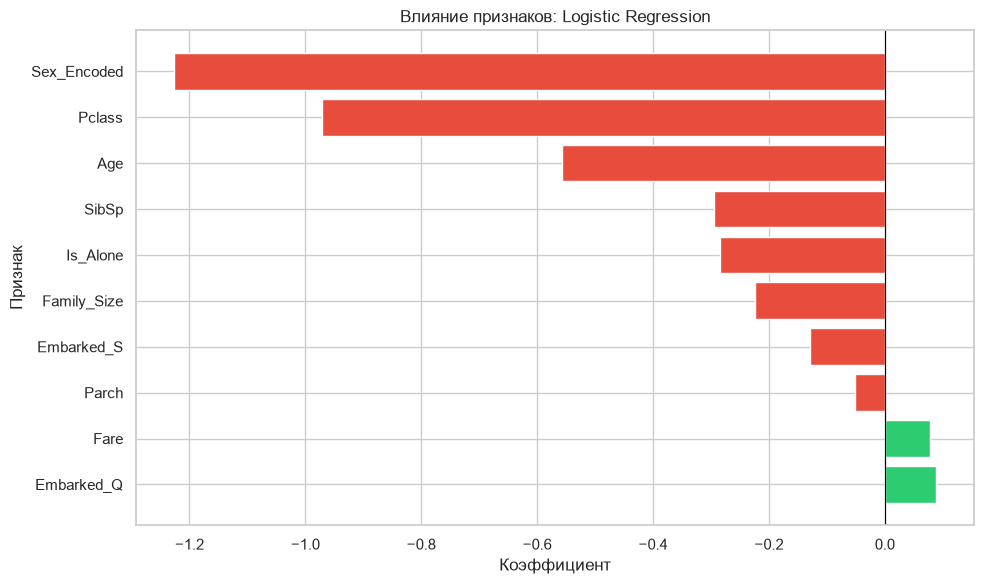

,Признак,Важность
1,Sex_Encoded,0.547662
0,Pclass,0.186186
5,Fare,0.105210
2,Age,0.099922
6,Family_Size,0.056601
4,Parch,0.002740
3,SibSp,0.001678
7,Is_Alone,0.000000
8,Embarked_Q,0.000000
9,Embarked_S,0.000000


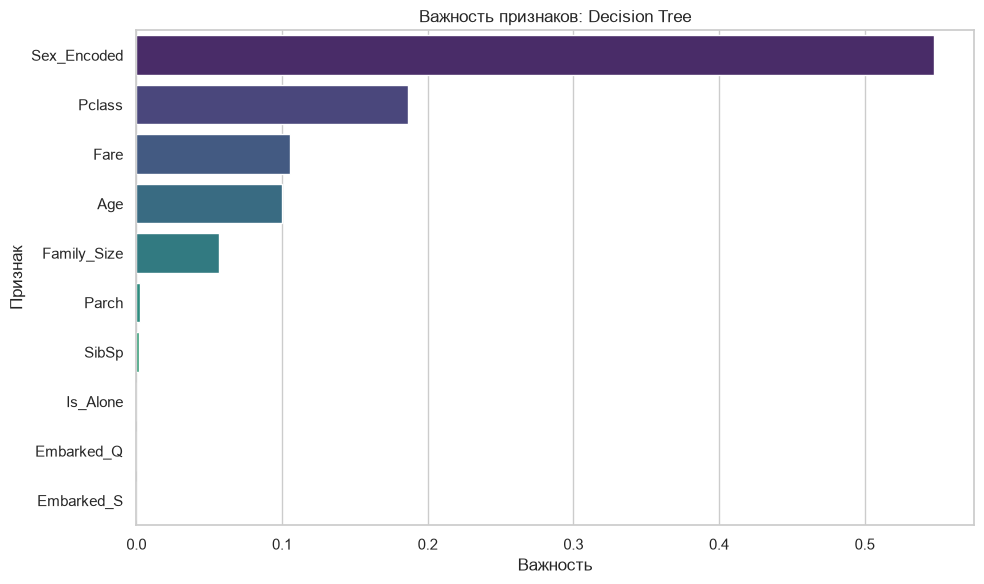

Выживаемость по полу:


Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

Выживаемость по классу:


Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

Выживаемость по признаку Is_Alone:


Is_Alone
0    50.56
1    30.35
Name: Survived, dtype: float64

In [13]:
# Создаём таблицу коэффициентов Logistic Regression.
coefficients = pd.DataFrame({
    "Признак": feature_cols,
    "Коэффициент": lr_model.coef_[0]
}).sort_values("Коэффициент", ascending=False)

# Выводим таблицу коэффициентов.
display(coefficients)

# Задаём цвет: зелёный для положительных и красный для отрицательных коэффициентов.
coefficient_colors = [
    "#2ecc71" if value > 0 else "#e74c3c"
    for value in coefficients["Коэффициент"]
]

# Создаём график коэффициентов.
plt.figure(figsize=(10, 6))

# Строим горизонтальную диаграмму коэффициентов.
plt.barh(
    coefficients["Признак"],
    coefficients["Коэффициент"],
    color=coefficient_colors
)

# Добавляем вертикальную линию нулевого влияния.
plt.axvline(0, color="black", linewidth=0.8)

# Подписываем оси и заголовок.
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.title("Влияние признаков: Logistic Regression")

# Настраиваем расположение элементов.
plt.tight_layout()

# Показываем график.
plt.show()

# Создаём таблицу важности признаков дерева решений.
importances = pd.DataFrame({
    "Признак": feature_cols,
    "Важность": dt_model.feature_importances_
}).sort_values("Важность", ascending=False)

# Выводим таблицу важности признаков дерева.
display(importances)

# Создаём график важности признаков дерева.
plt.figure(figsize=(10, 6))

# Строим горизонтальную диаграмму важности признаков.
sns.barplot(
    data=importances,
    x="Важность",
    y="Признак",
    hue="Признак",
    palette="viridis",
    legend=False
)

# Добавляем заголовок графика.
plt.title("Важность признаков: Decision Tree")

# Настраиваем размещение элементов.
plt.tight_layout()

# Показываем график.
plt.show()

# Рассчитываем фактическую долю выживших по полу.
survival_by_sex = train_df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)

# Рассчитываем фактическую долю выживших по классу.
survival_by_class = train_df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)

# Рассчитываем фактическую долю выживших для одиноких и не одиноких пассажиров.
survival_by_alone = train_processed.groupby("Is_Alone")["Survived"].mean()

# Выводим бизнес-инсайты с реальными значениями.
print("Выживаемость по полу:")
display((survival_by_sex * 100).round(2))

print("Выживаемость по классу:")
display((survival_by_class * 100).round(2))

print("Выживаемость по признаку Is_Alone:")
display((survival_by_alone * 100).round(2))


### Интерпретация

**Logistic Regression.** В модели Logistic Regression положительный коэффициент означает увеличение прогнозируемых шансов выживания, а отрицательный — уменьшение шансов при увеличении признака, если остальные признаки остаются неизменными. Поскольку числовые признаки были масштабированы с помощью `StandardScaler`, величины коэффициентов можно сопоставлять между собой с осторожностью.

Наиболее заметные коэффициенты Logistic Regression:

| Признак | Коэффициент | Интерпретация |
|---|---:|---|
| `Embarked_Q` | 0.0881 | Посадка в Queenstown связана с небольшим увеличением прогнозируемых шансов выживания относительно базовой категории порта C. |
| `Fare` | 0.0772 | Более высокая стоимость билета связана с небольшим увеличением прогнозируемых шансов выживания. |
| `Parch` | -0.0512 | Большее число родителей или детей на борту связано с небольшим уменьшением прогнозируемых шансов в данной модели. |
| `Embarked_S` | -0.1292 | Посадка в Southampton связана с небольшим снижением шансов выживания относительно порта C. |
| `Family_Size` | -0.2238 | Увеличение размера семьи связано со снижением прогнозируемых шансов выживания. |
| `Is_Alone` | -0.2837 | Путешествие в одиночку связано со снижением прогнозируемых шансов выживания. |
| `SibSp` | -0.2948 | Большее число супругов, братьев или сестёр связано со снижением прогнозируемых шансов выживания. |
| `Age` | -0.5572 | С увеличением возраста прогнозируемая вероятность выживания уменьшается. |
| `Pclass` | -0.9713 | Чем больше номер класса билета, тем ниже прогнозируемые шансы выживания. Следовательно, пассажиры первого класса имели преимущество относительно пассажиров второго и третьего классов. |
| `Sex_Encoded` | -1.2259 | Это самый сильный коэффициент по модулю. Если кодировка имеет вид `female = 0`, `male = 1`, то переход от женщины к мужчине существенно снижает прогнозируемые шансы выживания. |

**Decision Tree.** Важность признака показывает, насколько часто и эффективно он использовался деревом при разделении пассажиров на классы. Важность не показывает направление влияния и не является причинным эффектом.

| Признак | Важность |
|---|---:|
| `Sex_Encoded` | 0.5477 |
| `Pclass` | 0.1862 |
| `Fare` | 0.1052 |
| `Age` | 0.0999 |
| `Family_Size` | 0.0566 |
| `Parch` | 0.0027 |
| `SibSp` | 0.0017 |
| `Is_Alone` | 0.0000 |
| `Embarked_Q` | 0.0000 |
| `Embarked_S` | 0.0000 |

По Decision Tree наиболее важным признаком также оказался `Sex_Encoded`: его важность равна `0.5477`. Это означает, что более половины суммарной важности разбиений дерева связано с полом пассажира. На втором месте находится `Pclass` с важностью `0.1862`, затем следуют `Fare`, `Age` и `Family_Size`. Признаки порта посадки в ограниченном дереве не использовались для итоговых разбиений, поэтому их важность равна нулю.

**Бизнес-инсайты:**

1. Пол пассажира оказался главным признаком в обеих моделях. Для правильной интерпретации необходимо учитывать кодировку: в используемом `LabelEncoder` обычно `female = 0`, а `male = 1`. Отрицательный коэффициент `Sex_Encoded = -1.2259` означает, что при переходе от женщины к мужчине прогнозируемая вероятность выживания заметно уменьшается.
2. Класс билета является вторым по важности признаком дерева и имеет сильный отрицательный коэффициент в Logistic Regression (`-0.9713`). Более высокий номер класса означает менее престижный класс, поэтому пассажиры первого класса имели более высокие шансы выживания, чем пассажиры третьего класса.
3. Стоимость билета имеет положительный коэффициент (`0.0772`) и важность в дереве `0.1052`. Она может быть косвенным показателем класса обслуживания и социально-экономического положения пассажира.
4. Возраст имеет отрицательный коэффициент (`-0.5572`) и входит в число пяти наиболее важных признаков дерева. В рамках этой модели увеличение возраста связано со снижением прогнозируемой вероятности выживания.
5. Размер семьи имеет отрицательный коэффициент (`-0.2238`) и некоторую важность в дереве (`0.0566`). Однако признаки `Family_Size`, `SibSp`, `Parch` и `Is_Alone` связаны между собой, поэтому их индивидуальную интерпретацию нужно проводить осторожно.
6. Порт посадки оказывает значительно меньшее влияние, чем пол, класс билета, возраст и стоимость билета. В Decision Tree признаки `Embarked_Q` и `Embarked_S` не вошли в итоговые правила разбиения.
7. Полученные закономерности описывают именно историческую выборку пассажиров «Титаника». Они показывают статистические связи в данных, но не доказывают причинно-следственные зависимости и не должны переноситься на другие ситуации без дополнительной проверки.


## Функция предсказания

Функция `predict_passenger()` принимает данные нового пассажира, выполняет те же преобразования, что и при обучении: создаёт новые признаки, кодирует пол и порт посадки, выстраивает признаки в правильном порядке и при необходимости применяет масштабирование. Затем функция возвращает предсказанный класс и вероятность выживания.


In [14]:
def predict_passenger(passenger_data, model, scaler, feature_cols, le_sex, use_scaling=True):
    """
    Предсказывает выживание нового пассажира.
    
    Параметры:
    passenger_data : dict
        Словарь с ключами Pclass, Sex, Age, SibSp, Parch, Fare, Embarked.
    model : sklearn model
        Обученная модель Logistic Regression или Decision Tree.
    scaler : StandardScaler or None
        Обученный scaler для Logistic Regression.
    feature_cols : list
        Список признаков в корректном порядке.
    le_sex : LabelEncoder
        Обученный кодировщик пола.
    use_scaling : bool
        Нужно ли применять масштабирование.
    
    Возвращает:
    tuple
        Класс 0/1 и вероятность выживания.
    """
    
    # Создаём копию словаря, чтобы не менять входные данные.
    passenger = passenger_data.copy()
    
    # Создаём размер семьи аналогично обучающей выборке.
    passenger["Family_Size"] = passenger["SibSp"] + passenger["Parch"] + 1
    
    # Создаём признак путешествия в одиночку.
    passenger["Is_Alone"] = int(passenger["Family_Size"] == 1)
    
    # Кодируем пол ранее обученным LabelEncoder.
    passenger["Sex_Encoded"] = le_sex.transform([passenger["Sex"]])[0]
    
    # Создаём one-hot признаки порта посадки.
    passenger["Embarked_Q"] = int(passenger["Embarked"] == "Q")
    passenger["Embarked_S"] = int(passenger["Embarked"] == "S")
    
    # Формируем DataFrame строго с нужными признаками и их порядком.
    X_new = pd.DataFrame([{
        "Pclass": passenger["Pclass"],
        "Sex_Encoded": passenger["Sex_Encoded"],
        "Age": passenger["Age"],
        "SibSp": passenger["SibSp"],
        "Parch": passenger["Parch"],
        "Fare": passenger["Fare"],
        "Family_Size": passenger["Family_Size"],
        "Is_Alone": passenger["Is_Alone"],
        "Embarked_Q": passenger["Embarked_Q"],
        "Embarked_S": passenger["Embarked_S"]
    }])[feature_cols]
    
    # Масштабируем признаки только при использовании Logistic Regression.
    if use_scaling:
        X_for_prediction = scaler.transform(X_new)
    else:
        X_for_prediction = X_new
    
    # Получаем предсказанный класс.
    prediction = int(model.predict(X_for_prediction)[0])
    
    # Получаем вероятность положительного класса.
    probability = float(model.predict_proba(X_for_prediction)[0, 1])
    
    # Возвращаем класс и вероятность.
    return prediction, probability


# Создаём минимум пять тестовых профилей пассажиров.
passenger_examples = [
    {
        "name": "Пример 1: женщина, 1 класс",
        "data": {
            "Pclass": 1,
            "Sex": "female",
            "Age": 25,
            "SibSp": 1,
            "Parch": 0,
            "Fare": 100.0,
            "Embarked": "C"
        }
    },
    {
        "name": "Пример 2: мужчина, 3 класс",
        "data": {
            "Pclass": 3,
            "Sex": "male",
            "Age": 30,
            "SibSp": 0,
            "Parch": 0,
            "Fare": 7.25,
            "Embarked": "S"
        }
    },
    {
        "name": "Пример 3: ребёнок, 2 класс",
        "data": {
            "Pclass": 2,
            "Sex": "female",
            "Age": 5,
            "SibSp": 3,
            "Parch": 1,
            "Fare": 30.0,
            "Embarked": "S"
        }
    },
    {
        "name": "Пример 4: мужчина старшего возраста, 1 класс",
        "data": {
            "Pclass": 1,
            "Sex": "male",
            "Age": 60,
            "SibSp": 0,
            "Parch": 0,
            "Fare": 200.0,
            "Embarked": "C"
        }
    },
    {
        "name": "Пример 5: женщина, 3 класс",
        "data": {
            "Pclass": 3,
            "Sex": "female",
            "Age": 22,
            "SibSp": 0,
            "Parch": 0,
            "Fare": 8.0,
            "Embarked": "Q"
        }
    }
]

# Создаём список для итоговой таблицы результатов.
prediction_results = []

# Последовательно предсказываем выживание для каждого профиля.
for example in passenger_examples:
    
    # Извлекаем данные текущего пассажира.
    passenger_data = example["data"]
    
    # Получаем прогноз Logistic Regression.
    lr_prediction, lr_probability = predict_passenger(
        passenger_data,
        lr_model,
        scaler,
        feature_cols,
        le_sex,
        use_scaling=True
    )
    
    # Получаем прогноз Decision Tree без масштабирования.
    dt_prediction, dt_probability = predict_passenger(
        passenger_data,
        dt_model,
        None,
        feature_cols,
        le_sex,
        use_scaling=False
    )
    
    # Добавляем результат в итоговый список.
    prediction_results.append({
        "Пример": example["name"],
        "Данные": str(passenger_data),
        "LR: прогноз": "Выжил" if lr_prediction == 1 else "Не выжил",
        "LR: вероятность, %": round(lr_probability * 100, 2),
        "DT: прогноз": "Выжил" if dt_prediction == 1 else "Не выжил",
        "DT: вероятность, %": round(dt_probability * 100, 2),
        "Модели совпали": "Да" if lr_prediction == dt_prediction else "Нет"
    })

# Преобразуем результаты в DataFrame.
prediction_results_df = pd.DataFrame(prediction_results)

# Показываем предсказания всех пяти пассажиров.
display(prediction_results_df)


,Пример,Данные,LR: прогноз,"LR: вероятность, %",DT: прогноз,"DT: вероятность, %",Модели совпали
0,"Пример 1: женщина, 1 класс","{'Pclass': 1, 'Sex': 'female', 'Age': 25, 'Sib...",Выжил,96.11,Выжил,100.00,Да
1,"Пример 2: мужчина, 3 класс","{'Pclass': 3, 'Sex': 'male', 'Age': 30, 'SibSp...",Не выжил,7.61,Не выжил,11.00,Да
2,"Пример 3: ребёнок, 2 класс","{'Pclass': 2, 'Sex': 'female', 'Age': 5, 'SibS...",Выжил,80.79,Выжил,100.00,Да
3,"Пример 4: мужчина старшего возраста, 1 класс","{'Pclass': 1, 'Sex': 'male', 'Age': 60, 'SibSp...",Не выжил,30.56,Не выжил,30.91,Да
4,"Пример 5: женщина, 3 класс","{'Pclass': 3, 'Sex': 'female', 'Age': 22, 'Sib...",Выжил,73.51,Выжил,53.49,Да


**Вывод по демонстрации:** функция успешно принимает новые данные, выполняет те же преобразования, что использовались при обучении, и выдаёт предсказанный класс вместе с вероятностью выживания. Расхождение Logistic Regression и Decision Tree на некоторых профилях допустимо, поскольку модели используют разные принципы принятия решений.


## Сохранение модели и вспомогательных объектов

Чтобы использовать модель без повторного обучения, сохраняются:

- Logistic Regression;
- Decision Tree;
- StandardScaler;
- LabelEncoder для пола;
- список признаков в правильном порядке;
- метрики моделей в JSON-формате.

Все файлы сохраняются в папке `models/` внутри модуля.


In [15]:
# Импортируем joblib для сериализации моделей и трансформеров.
import joblib

# Импортируем json для сохранения метаданных.
import json

# Сохраняем обученную Logistic Regression.
joblib.dump(lr_model, "models/lr_model.pkl")

# Сохраняем обученное дерево решений.
joblib.dump(dt_model, "models/dt_model.pkl")

# Сохраняем обученный StandardScaler.
joblib.dump(scaler, "models/scaler.pkl")

# Сохраняем обученный LabelEncoder пола.
joblib.dump(le_sex, "models/le_sex.pkl")

# Сохраняем список признаков с правильным порядком.
with open("models/feature_cols.json", "w", encoding="utf-8") as file:
    json.dump(feature_cols, file, ensure_ascii=False, indent=2)

# Формируем словарь метрик для обеих моделей.
metrics_to_save = {
    "logistic_regression": {
        "accuracy": float(lr_metrics["Accuracy"]),
        "precision": float(lr_metrics["Precision"]),
        "recall": float(lr_metrics["Recall"]),
        "f1": float(lr_metrics["F1"]),
        "roc_auc": float(lr_metrics["ROC-AUC"]),
        "training_time_sec": float(lr_time)
    },
    "decision_tree": {
        "accuracy": float(dt_metrics["Accuracy"]),
        "precision": float(dt_metrics["Precision"]),
        "recall": float(dt_metrics["Recall"]),
        "f1": float(dt_metrics["F1"]),
        "roc_auc": float(dt_metrics["ROC-AUC"]),
        "training_time_sec": float(dt_time)
    }
}

# Сохраняем метрики в JSON-файл.
with open("models/metrics.json", "w", encoding="utf-8") as file:
    json.dump(metrics_to_save, file, ensure_ascii=False, indent=2)

# Проверяем содержимое папки моделей.
print("Файлы в папке models/:")
print(sorted(__import__("os").listdir("models")))

# Сообщаем об успешном сохранении.
print("✅ Модели, трансформеры, признаки и метрики сохранены.")


Файлы в папке models/:
['dt_model.pkl', 'feature_cols.json', 'le_sex.pkl', 'lr_model.pkl', 'metrics.json', 'scaler.pkl']
✅ Модели, трансформеры, признаки и метрики сохранены.


## Загрузка модели из репозитория и быстрый инференс

Цель этого раздела — проверить, что сохранённая модель может быть загружена напрямую из GitHub без повторного обучения. Для этого используется raw-ссылка на файлы в ветке `main`.

После загрузки выполняются предсказания для трёх пассажиров. Результаты должны совпадать с предсказаниями исходной модели из раздела 9.
